<a href="https://colab.research.google.com/github/tojotk/IMDb_Movie_Reviews/blob/Model-Building/IMDb_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [53]:
# Data manipulation and numerical computations
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

# Natural Language Processing (NLP)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")
#Text preprocessing
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer


from sklearn.preprocessing import LabelEncoder # Convert categorical labels
from sklearn.model_selection import train_test_split # Split the dataset into training and testing sets for model evaluation.
from sklearn.feature_extraction.text import TfidfVectorizer # Convert text documents into numerical feature vectors using the TF-IDF technique.

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Save trained models
import joblib

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Read dataset

In [7]:
df_movie = pd.read_csv('/content/drive/MyDrive/AI ML Course/Data/IMDB Dataset.csv')
df_movie.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# EDA

In [8]:
df_movie.shape

(50000, 2)

In [9]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
df_movie.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [11]:
df_movie.isnull().sum()

,0
review,0
sentiment,0


In [12]:
# view sentiment distrubution
df_movie["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Plot Visulaization

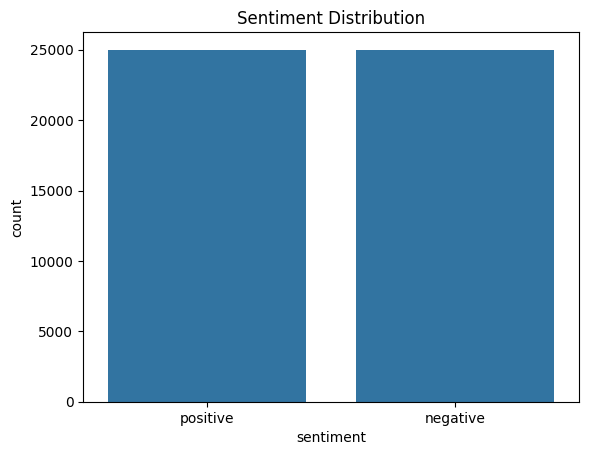

In [13]:
# Draw bar chart
sns.countplot(x="sentiment", data=df_movie)
plt.title("Sentiment Distribution")
plt.show()

In [14]:
# Checking review length

In [15]:
# Count number of words in each review
df_movie["Review_Length"] = df_movie["review"].apply(lambda x: len(x.split()))
df_movie["Review_Length"].head()

,Review_Length
0,307
1,162
2,166
3,138
4,230


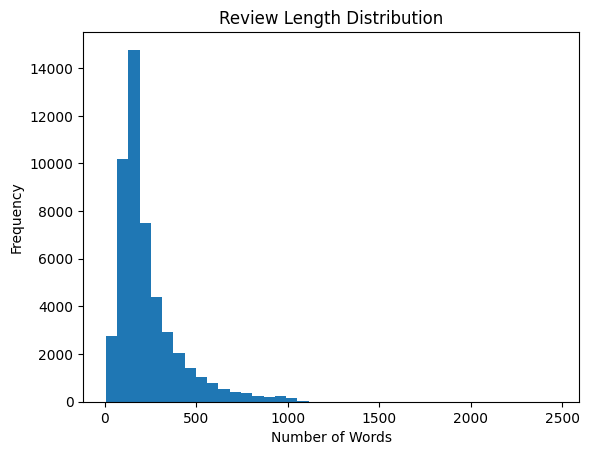

In [16]:
# Plot histogram
plt.hist(df_movie["Review_Length"], bins=40)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")

plt.show()

# Text Preprocessing

## Duplicates removal

In [17]:
df_movie.duplicated().sum()

np.int64(418)

In [18]:
df_movie.drop_duplicates(inplace=True)

In [19]:
df_movie.duplicated().sum()

np.int64(0)

## Missing value

In [20]:
df_movie.isnull().sum()

,0
review,0
sentiment,0
Review_Length,0


## Remove html tags

In [21]:
# Function to remove HTML tags
def remove_html(text):
    clean = re.compile("<.*?>")
    return re.sub(clean, "", text)
df_movie["review"] = df_movie["review"].apply(remove_html)

## Convert to lowercase

In [22]:
# Convert all text into lowercase
df_movie["review"] = df_movie["review"].str.lower()

## Remove Punctuations

In [23]:
# Function to remove punctuation
def remove_punctuation(text):
    # Remove punctuation characters
    return text.translate(str.maketrans("", "", string.punctuation))
df_movie["review"] = df_movie["review"].apply(remove_punctuation)

## Tokenazation

In [24]:
# Convert sentence into list of words
df_movie["Tokens"] = df_movie["review"].apply(word_tokenize)
# Display first review tokens
df_movie["Tokens"].head()

,Tokens
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."


## Remove Stopwords

In [25]:
# Load  stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords
df_movie["Tokens"] = df_movie["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

## Stemming

In [26]:
# Create stemmer object
stemmer = PorterStemmer()

# Apply stemming
df_movie["Stemmed"] = df_movie["Tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

## Lemmatization

In [27]:
# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_movie["Lemmatized"] = df_movie["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

## Convert tokens back to sentence

In [28]:
# Join words into a sentence
df_movie["Clean_Review"] = df_movie["Lemmatized"].apply(lambda words: " ".join(words))

# Display cleaned reviews
df_movie[["review", "Clean_Review"]].head()

,review,Clean_Review
0,one of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


In [29]:
df_movie.head()

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,positive,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,positive,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,negative,138,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,positive,230,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


#Model Building

Esha

##Encode the Target Variable

In [55]:
# Convert the target labels ('positive' and 'negative')
# into numerical values (1 and 0) for machine learning models.
label_enc = LabelEncoder()

df_movie["sentiment"] = label_enc.fit_transform(df_movie["sentiment"])
# Display the number of positive and negative reviews.
df_movie["sentiment"].value_counts()

,count
sentiment,
1,24884
0,24698


In [31]:
df_movie.head(3)

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,1,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,1,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,1,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...


##Split Features and Target

In [32]:
# Define the input feature (cleaned review text)
# and the target variable (sentiment).

X = df_movie["Clean_Review"]

y = df_movie["sentiment"]

##Train-Test Split

In [34]:
# Split the dataset into training and testing sets.
# Stratify ensures both sets maintain the same proportion of positive and negative reviews.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Display the size of the training and testing datasets.
print(X_train.shape)
print(X_test.shape)

(39665,)
(9917,)


##Convert Text into Numbers using TF-IDF

In [56]:
# Convert the cleaned text into numerical feature vectors
# using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.
tfidf = TfidfVectorizer(
    max_features=10000,    #Keep only the top 10,000 important words.
    ngram_range=(1,2)      #Use both single words and pairs of words.

)
# Learn the vocabulary from the training data and transform the text into TF-IDF vectors.
X_train_tfidf = tfidf.fit_transform(X_train)
# Transform the test data using the same vocabulary.
X_test_tfidf = tfidf.transform(X_test)

In [36]:
# Display the dimensions of the TF-IDF matrices.
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(39665, 10000)
(9917, 10000)


##Train Logistic Regression

In [41]:
# Create a Logistic Regression classifier
# and train it using the TF-IDF feature vectors.
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)
# Predict the sentiment labels for the unseen test dataset.
y_pred_lr = model.predict(X_test_tfidf)

# Calculate the overall accuracy of the trained model.
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)

Accuracy : 0.8916002823434507


##Compare Multiple Models

In [57]:
# Train and compare multiple machine learning algorithms
# to identify the best-performing classifier for sentiment analysis.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    print(f"{name}: {accuracy_score(y_test, pred):.4f}")

Logistic Regression: 0.8916
Multinomial NB: 0.8658
Linear SVM: 0.8860
Random Forest: 0.8480


##Classification Report for Logistic Regression

In [43]:
# Display Precision, Recall, F1-score, and Support for each sentiment class.

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



##Confusion Matrix for Logistic Regression

In [45]:
# Generate the confusion matrix to compare actual labels with predicted labels.

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[4348  592]
 [ 483 4494]]


###Plot Confusion Matrix

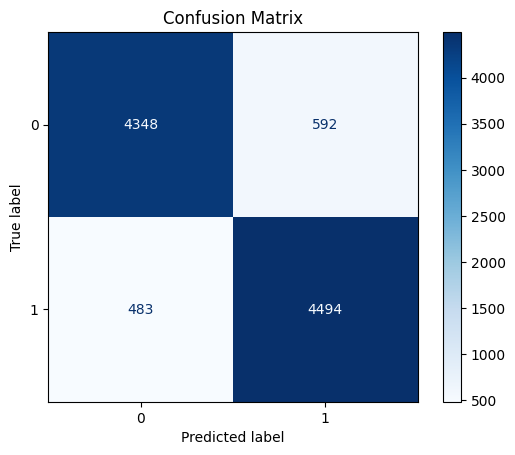

In [48]:
# Display the confusion matrix using a heatmap-style visualization.

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

##Predict on a New Review

In [49]:
# Predict the sentiment of a new movie review  entered by the user.

review = ["This movie was absolutely fantastic. I loved every scene."]

review = tfidf.transform(review)

prediction = model.predict(review)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [50]:
# Test the model using another example review.

review1 = ["Worst movie ever. Waste of time."]

review1 = tfidf.transform(review1)

prediction = model.predict(review1)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


##Save the Model

In [52]:
# Save the trained Logistic Regression model and the TF-IDF vectorizer for future use.

joblib.dump(model, "imdb_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']